### In this notebook we just make a comparaison of loading methodes on spark
- **Data Ingestion**: We will learn how to read different formats (CSV, JSON) and how Spark automatically infers the "schema" (the structure of columns and data types).

- **Lazy Evaluation**: This is Spark’s “superpower.” We will see that Spark does not execute operations as soon as we write them; instead, it builds a logical plan and only performs computations when we request a final result.

- **Transformations vs. Actions**: We will distinguish between commands that create a new dataset (such as filtering) and those that return a result (such as counting or displaying data).

- **DAG (Directed Acyclic Graph)**: We will explore how Spark internally represents the sequence of steps required to reach a result.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql import functions as F
import time

_t = {}

def ts(lbl):
    _t[lbl] = time.perf_counter()
    print(f'[START] {lbl}')

def te(lbl):
    e = time.perf_counter() - _t[lbl]
    print(f'[END]   {lbl}  ->  {e:.4f}s')
    return e

def sep(t=''):
    print('\n' + '='*70)
    if t:
        print(f'  {t}')
        print('='*70)


In [2]:
from pyspark.sql import SparkSession

# Create a fresh session
spark = SparkSession.builder\
    .appName("NetworkTraffic_Analysis")\
    .master("spark://spark-master:7077")\
    .config("spark.executor.memory", "512m")\
    .config("spark.executor.cores", "1")\
    .config("spark.driver.memory", "512m")\
    .getOrCreate()


# SECTION 1 – InferSchema vs Manual StructType
We load the same CSV two ways, time each, then compare schemas field-by-field.

In [3]:
# Cambia esto:
# CSV_PATH = 'data/Midterm_53_group.csv' 

# Por esto (ruta absoluta interna del contenedor):
CSV_PATH = '/opt/spark/data/Midterm_53_group.csv'

# Si el archivo está dentro de una carpeta llamada "archive" en tu escritorio, sería:
# CSV_PATH = '/opt/spark/data/archive/Midterm_53_group.csv'

sep('1A. inferSchema=true')
ts('Read CSV - inferSchema')
df_infer = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv(CSV_PATH))


  1A. inferSchema=true
[START] Read CSV - inferSchema


In [4]:
import time

ts_start = time.time() 

df_infer = (spark.read
    .option('header', 'true')
    .option('inferSchema', 'true')
    .csv('/opt/spark/data/Midterm_53_group.csv'))

count_val = df_infer.count() 

t_infer = time.time() - ts_start # Define the variable
print(f"InferSchema finished in {t_infer:.4f} seconds.")

InferSchema finished in 2.0419 seconds.


In [5]:
sep('1B. Manual StructType')
manual_schema = StructType([
    StructField('No.',          IntegerType(), True),
    StructField('Time',        DoubleType(),  True),
    StructField('Source',      StringType(),  True),
    StructField('Destination', StringType(),  True),
    StructField('Protocol',    StringType(),  True),
    StructField('Length',      IntegerType(), True),
    StructField('Info',        StringType(),  True),
])
ts('Read CSV - manual schema')
df_manual = (spark.read
    .schema(manual_schema)
    .option('header', 'true')
    .csv(CSV_PATH))
cnt_m = df_manual.count()
t_manual = te('Read CSV - manual schema')
print(f'Rows: {cnt_m:,}')
df_manual.printSchema()



  1B. Manual StructType
[START] Read CSV - manual schema
[END]   Read CSV - manual schema  ->  0.5719s
Rows: 394,136
root
 |-- No.: integer (nullable = true)
 |-- Time: double (nullable = true)
 |-- Source: string (nullable = true)
 |-- Destination: string (nullable = true)
 |-- Protocol: string (nullable = true)
 |-- Length: integer (nullable = true)
 |-- Info: string (nullable = true)



In [6]:
sep('1C. Schema comparison + timing')
it = {f.name: f.dataType.simpleString() for f in df_infer.schema.fields}
mt = {f.name: f.dataType.simpleString() for f in df_manual.schema.fields}

print(f"{'Column':<18} {'Inferred':<20} {'Manual':<20} Match?")
print('-' * 65)
mismatches = []
for col in sorted(set(it) | set(mt)):
    iv = it.get(col, 'MISSING')
    mv = mt.get(col, 'MISSING')
    ok = 'OK' if iv == mv else 'DIFF'
    if iv != mv:
        mismatches.append(col)
    print(f'{col:<18} {iv:<20} {mv:<20} {ok}')

print()
if mismatches:
    print(f'Type differences on: {mismatches}')
    print('  Spark infers LongType for integer cols; manual schema gives full control.')
else:
    print('All column types match.')

print(f'\nTime inferSchema : {t_infer:.4f}s')
print(f'Time manual      : {t_manual:.4f}s')
ratio = t_infer / t_manual if t_manual else 0
print(f'Manual is {ratio:.2f}x faster (skips the extra type-inference scan)')



  1C. Schema comparison + timing
Column             Inferred             Manual               Match?
-----------------------------------------------------------------
Destination        string               string               OK
Info               string               string               OK
Length             int                  int                  OK
No.                int                  int                  OK
Protocol           string               string               OK
Source             string               string               OK
Time               double               double               OK

All column types match.

Time inferSchema : 2.0419s
Time manual      : 0.5719s
Manual is 3.57x faster (skips the extra type-inference scan)


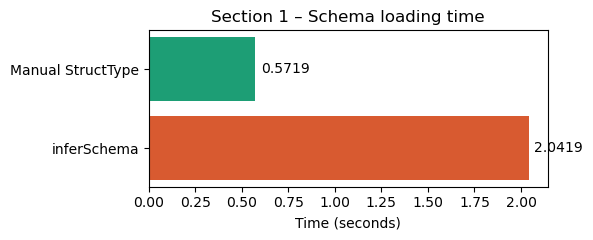

In [7]:
import matplotlib.pyplot as plt

labels = ['inferSchema', 'Manual StructType']
times  = [t_infer, t_manual]
colors = ['#D85A30', '#1D9E75']

fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.barh(labels, times, color=colors)
ax.set_xlabel('Time (seconds)')
ax.set_title('Section 1 – Schema loading time')
ax.bar_label(bars, fmt='%.4f', padding=4)
plt.tight_layout()
plt.show()

# SECTION 2 – Lazy Evaluation
Transformations build a logical plan in microseconds. Only actions trigger execution.

In [8]:
sep('2A. Building transformation chain (LAZY - nothing runs yet)')
df = df_manual

ts('T1 filter Length>60')
df_t1 = df.filter(F.col('Length') > 60)
t1 = te('T1 filter Length>60')

ts('T2 select columns')
df_t2 = df_t1.select('Time', 'Source', 'Destination', 'Protocol', 'Length')
t2 = te('T2 select columns')

ts('T3 withColumn PacketSize category')
df_t3 = df_t2.withColumn(
    'PacketSize',
    F.when(F.col('Length') < 100, 'Small')
     .when((F.col('Length') >= 100) & (F.col('Length') < 500), 'Medium')
     .otherwise('Large')
)
t3 = te('T3 withColumn PacketSize category')

ts('T4 groupBy Protocol agg')
df_t4 = (df_t3
    .groupBy('Protocol')
    .agg(
        F.count('*').alias('PacketCount'),
        F.avg('Length').alias('AvgLength'),
        F.max('Length').alias('MaxLength')
    )
    .orderBy(F.desc('PacketCount')))
t4 = te('T4 groupBy Protocol agg')

ts('T5 round AvgLength')
df_t5 = df_t4.withColumn('AvgLength', F.round('AvgLength', 2))
t5 = te('T5 round AvgLength')

total_lazy = t1 + t2 + t3 + t4 + t5
print(f'\nTotal plan-build time: {total_lazy:.6f}s  <- near-zero, NO data touched')
df_t5.explain(mode='simple')



  2A. Building transformation chain (LAZY - nothing runs yet)
[START] T1 filter Length>60
[END]   T1 filter Length>60  ->  0.0296s
[START] T2 select columns
[END]   T2 select columns  ->  0.0257s
[START] T3 withColumn PacketSize category
[END]   T3 withColumn PacketSize category  ->  0.0272s
[START] T4 groupBy Protocol agg
[END]   T4 groupBy Protocol agg  ->  0.0466s
[START] T5 round AvgLength
[END]   T5 round AvgLength  ->  0.0149s

Total plan-build time: 0.143906s  <- near-zero, NO data touched
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [Protocol#78, PacketCount#120L, round(AvgLength#122, 2) AS AvgLength#129, MaxLength#124]
   +- Sort [PacketCount#120L DESC NULLS LAST], true, 0
      +- Exchange rangepartitioning(PacketCount#120L DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=128]
         +- HashAggregate(keys=[Protocol#78], functions=[count(1), avg(Length#79), max(Length#79)])
            +- Exchange hashpartitioning(Protocol#78, 200), ENSURE_REQUIREM

In [9]:
sep('2B. ACTION: show(10) triggers ALL 5 transformations')
ts('ACTION show(10)')
df_t5.show(10)
t_action = te('ACTION show(10)')

print(f'\nTime - 5 transformations planned : {total_lazy:.6f}s')
print(f'Time - 1 action executed them    : {t_action:.4f}s')
print(f'Execution/planning ratio         : {t_action/total_lazy:.0f}x')



  2B. ACTION: show(10) triggers ALL 5 transformations
[START] ACTION show(10)
+--------+-----------+---------+---------+
|Protocol|PacketCount|AvgLength|MaxLength|
+--------+-----------+---------+---------+
|     TCP|     202045|  1512.63|    14174|
| TLSv1.3|      71433|  1047.51|    49745|
|    ICMP|       2360|    98.19|      321|
|     DNS|       1999|   128.81|      824|
| TLSv1.2|       1750|   581.71|     5894|
|    OCSP|        258|   630.13|     1253|
|    NBNS|        231|    98.39|      110|
|   TLSv1|         20|    567.0|      567|
|    DHCP|         17|   354.35|      370|
|   SSLv2|         11|   1498.0|     1514|
+--------+-----------+---------+---------+
only showing top 10 rows

[END]   ACTION show(10)  ->  2.0622s

Time - 5 transformations planned : 0.143906s
Time - 1 action executed them    : 2.0622s
Execution/planning ratio         : 14x


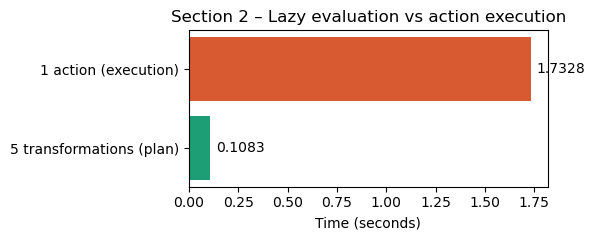

In [12]:
labels = ['5 transformations (plan)', '1 action (execution)']
times  = [total_lazy, t_action]
colors = ['#1D9E75', '#D85A30']

fig, ax = plt.subplots(figsize=(6, 2.5))
bars = ax.barh(labels, times, color=colors)
ax.set_xlabel('Time (seconds)')
ax.set_title('Section 2 – Lazy evaluation vs action execution')
ax.bar_label(bars, fmt='%.4f', padding=4)
plt.tight_layout()
plt.show()

# SECTION 3 – Action-by-Action Timing
Different actions have different costs on the same DataFrame.

In [13]:
sep('3. Timing different actions on df_t3')
results = []

ts('A count()')
n = df_t3.count()
results.append(('count()', te('A count()'), f'rows={n:,}'))

ts('B first()')
row = df_t3.first()
results.append(('first()', te('B first()'), 'first row fetched'))

ts('C show(5)')
df_t3.show(5)
results.append(('show(5)', te('C show(5)'), 'printed 5 rows'))

ts('D describe(Length).show()')
df_t3.describe('Length').show()
results.append(('describe().show()', te('D describe(Length).show()'), 'stats on Length'))

ts('E collect()')
all_rows = df_t3.collect()
results.append(('collect()', te('E collect()'), f'fetched {len(all_rows):,} rows to driver'))

print()
print(f"{'Action':<22} {'Time(s)':>10}   Bar")
print('-' * 55)
for action, elapsed, note in results:
    bar = '#' * max(1, int(elapsed * 10))
    print(f'{action:<22} {elapsed:>10.4f}   {bar}  ({note})')



  3. Timing different actions on df_t3
[START] A count()
[END]   A count()  ->  0.7496s
[START] B first()
[END]   B first()  ->  0.2285s
[START] C show(5)
+----+------+---------------+--------+------+----------+
|Time|Source|    Destination|Protocol|Length|PacketSize|
+----+------+---------------+--------+------+----------+
|NULL|     1|192.167.255.255|    NBNS|    92|     Small|
|NULL|     2|192.167.255.255|    NBNS|    92|     Small|
|NULL|    26|192.167.255.255| BROWSER|   243|    Medium|
|NULL|    28|        ff02::1|  ICMPv6|    86|     Small|
|NULL|    36|192.167.255.255|    NBNS|    92|     Small|
+----+------+---------------+--------+------+----------+
only showing top 5 rows

[END]   C show(5)  ->  0.2021s
[START] D describe(Length).show()
+-------+-----------------+
|summary|           Length|
+-------+-----------------+
|  count|           280148|
|   mean|1364.192566072219|
| stddev|700.5938890338151|
|    min|               61|
|    max|            49745|
+-------+--------

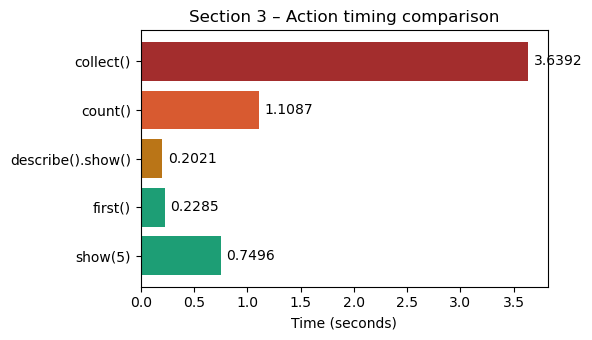

In [14]:
actions = ['show(5)', 'first()', 'describe().show()', 'count()', 'collect()']
times   = [r[1] for r in results]  # results list already built in your code
colors  = ['#1D9E75', '#1D9E75', '#BA7517', '#D85A30', '#A32D2D']

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(actions, times, color=colors)
ax.set_xlabel('Time (seconds)')
ax.set_title('Section 3 – Action timing comparison')
ax.bar_label(bars, fmt='%.4f', padding=4)
plt.tight_layout()
plt.show()

# SECTION 4 – Cache: Lazy Materialisation vs No Cache
`.cache()` is lazy; the first action stores data in executor memory for reuse.

In [15]:
sep('4. Cached vs Uncached repeated count()')
REPEATS = 3

uncached_times = []
for i in range(REPEATS):
    ts(f'Uncached run {i+1}')
    df_t3.count()
    uncached_times.append(te(f'Uncached run {i+1}'))

df_cached = df_t3.cache()
cached_times = []
for i in range(REPEATS):
    ts(f'Cached   run {i+1}')
    df_cached.count()
    cached_times.append(te(f'Cached   run {i+1}'))
df_cached.unpersist()

print(f'\nUncached avg : {sum(uncached_times)/REPEATS:.4f}s')
print(f'Cached   avg : {sum(cached_times)/REPEATS:.4f}s')
if cached_times[-1] > 0:
    print(f'Speedup (last run): {uncached_times[-1]/cached_times[-1]:.2f}x')
print('1st cached run materialises data; later runs hit RAM.')



  4. Cached vs Uncached repeated count()
[START] Uncached run 1
[END]   Uncached run 1  ->  0.4575s
[START] Uncached run 2
[END]   Uncached run 2  ->  0.4854s
[START] Uncached run 3
[END]   Uncached run 3  ->  0.4725s
[START] Cached   run 1
[END]   Cached   run 1  ->  2.5759s
[START] Cached   run 2
[END]   Cached   run 2  ->  0.1383s
[START] Cached   run 3
[END]   Cached   run 3  ->  0.0983s

Uncached avg : 0.4718s
Cached   avg : 0.9375s
Speedup (last run): 4.81x
1st cached run materialises data; later runs hit RAM.


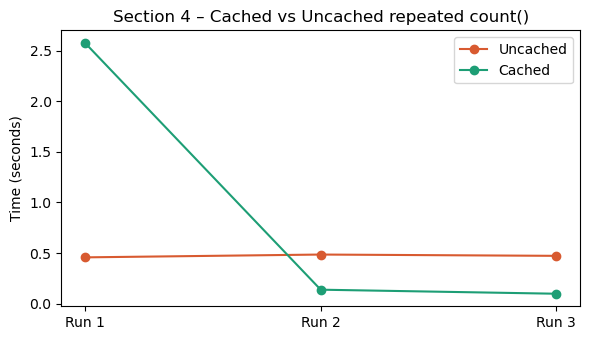

In [16]:
runs = ['Run 1', 'Run 2', 'Run 3']

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(runs, uncached_times, marker='o', color='#D85A30', label='Uncached')
ax.plot(runs, cached_times,   marker='o', color='#1D9E75', label='Cached')
ax.set_ylabel('Time (seconds)')
ax.set_title('Section 4 – Cached vs Uncached repeated count()')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
data= df_man

In [10]:
sep('FINAL SUMMARY')
print('''
KEY TAKEAWAYS
  inferSchema=true   -> convenient but scans file twice (slower)
  Manual StructType  -> single pass, type-safe, faster for production
  Transformations    -> LAZY: plan in microseconds, NO data read
  Actions            -> trigger full DAG (count, show, collect ...)
  cache()            -> lazy; 1st action materialises; later runs use RAM
''')
spark.stop()
print('Spark session stopped.')



  FINAL SUMMARY

KEY TAKEAWAYS
  inferSchema=true   -> convenient but scans file twice (slower)
  Manual StructType  -> single pass, type-safe, faster for production
  Transformations    -> LAZY: plan in microseconds, NO data read
  Actions            -> trigger full DAG (count, show, collect ...)
  cache()            -> lazy; 1st action materialises; later runs use RAM

Spark session stopped.
